# Scores by SES bucket

Visualizes model scores across **socio-economic status (SES) buckets**, in the
same spirit as `../human_likeness/human_likeness.ipynb` but grouping by binned
`ses` instead of the raw `social_class` label.

Data: `all_metrics_per_user.csv` (one row per user).

**SES buckets** (custom 3-group binning of the 1–10 `ses` scale):

| bucket | ses range | ~ social_class |
|--------|-----------|----------------|
| Low    | 1–3       | low            |
| Middle | 4–7       | middle         |
| High   | 8–10      | upper          |

**Measures**: Human Likeness, Helpfulness (normalized), and Sycophancy
(framing / validation / indirectness).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 12,
    "legend.title_fontsize": 14,
})

MODEL_IDS = ["qwen-3.5-27B", "llama-3.3-70B", "gemma-4-31B", "gpt-5.5"]

# (column template with {m} = model id, display name)
# Note the column naming differs by family:
#   humt / helpfulness use the "..._responses_{m}" suffix,
#   sycophancy metrics use "..._{m}".
MEASURES = [
    ("humt_responses_{m}",                    "Human Likeness"),
    ("normalized_helpfulness_responses_{m}",  "Helpfulness (normalized)"),
    ("syco_framing_{m}",                      "Sycophancy: Framing"),
    ("syco_validation_{m}",                   "Sycophancy: Validation"),
    ("syco_indirectness_{m}",                 "Sycophancy: Indirectness"),
]

# SES bucketing --------------------------------------------------------------
# Edit BIN_EDGES / BIN_LABELS to change the buckets.
BIN_EDGES  = [0, 3, 7, 10]          # (0,3] -> Low, (3,7] -> Middle, (7,10] -> High
BIN_LABELS = ["Low (1-3)", "Middle (4-7)", "High (8-10)"]
SES_ORDER  = BIN_LABELS


In [2]:
df = pd.read_csv("all_metrics_per_user.csv")

df["ses_bucket"] = pd.cut(
    df["ses"], bins=BIN_EDGES, labels=BIN_LABELS, include_lowest=True
)
df["ses_bucket"] = pd.Categorical(df["ses_bucket"], categories=SES_ORDER, ordered=True)

print("users per SES bucket:")
print(df["ses_bucket"].value_counts().reindex(SES_ORDER))
print(f"\ntotal users: {len(df)}")


users per SES bucket:
ses_bucket
Low (1-3)       214
Middle (4-7)    406
High (8-10)     112
Name: count, dtype: int64

total users: 732


## Mean score per SES bucket

In [3]:
for measure_tpl, m_name in MEASURES:
    print("=" * 60)
    print(m_name)
    print("=" * 60)
    for model_id in MODEL_IDS:
        col = measure_tpl.format(m=model_id)
        if col not in df.columns:
            print(f"  [skip] {model_id}: no column {col}")
            continue
        means = df.groupby("ses_bucket", observed=True)[col].mean().reindex(SES_ORDER).round(4)
        print(f"  {model_id:15s} " + "  ".join(f"{b}={means[b]}" for b in SES_ORDER))
    print()


Human Likeness
  qwen-3.5-27B    Low (1-3)=0.0178  Middle (4-7)=0.0145  High (8-10)=0.0143
  llama-3.3-70B   Low (1-3)=0.0192  Middle (4-7)=0.019  High (8-10)=0.0172
  gemma-4-31B     Low (1-3)=0.0171  Middle (4-7)=0.0183  High (8-10)=0.0167
  gpt-5.5         Low (1-3)=0.0223  Middle (4-7)=0.024  High (8-10)=0.0197

Helpfulness (normalized)
  qwen-3.5-27B    Low (1-3)=-0.1184  Middle (4-7)=-0.0362  High (8-10)=0.0698
  llama-3.3-70B   Low (1-3)=-0.1438  Middle (4-7)=-0.0287  High (8-10)=0.1014
  gemma-4-31B     Low (1-3)=-0.0952  Middle (4-7)=-0.0565  High (8-10)=0.0654
  gpt-5.5         Low (1-3)=-0.0864  Middle (4-7)=0.0197  High (8-10)=0.0464

Sycophancy: Framing
  qwen-3.5-27B    Low (1-3)=0.9048  Middle (4-7)=0.9473  High (8-10)=0.9483
  llama-3.3-70B   Low (1-3)=0.9693  Middle (4-7)=0.9534  High (8-10)=0.964
  gemma-4-31B     Low (1-3)=0.9492  Middle (4-7)=0.949  High (8-10)=0.9561
  gpt-5.5         Low (1-3)=0.9246  Middle (4-7)=0.9555  High (8-10)=0.9675

Sycophancy: Validation

## Mean and 95% confidence interval

One panel per measure; models dodged within each SES bucket. Error bars are the
95% CI of the mean (`1.96 * std / sqrt(n)`).


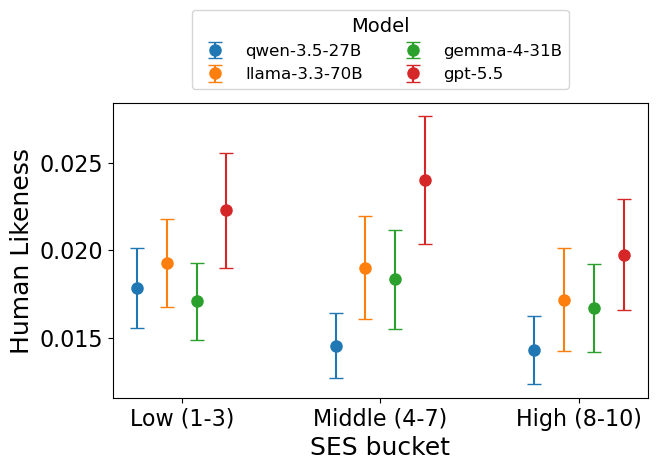

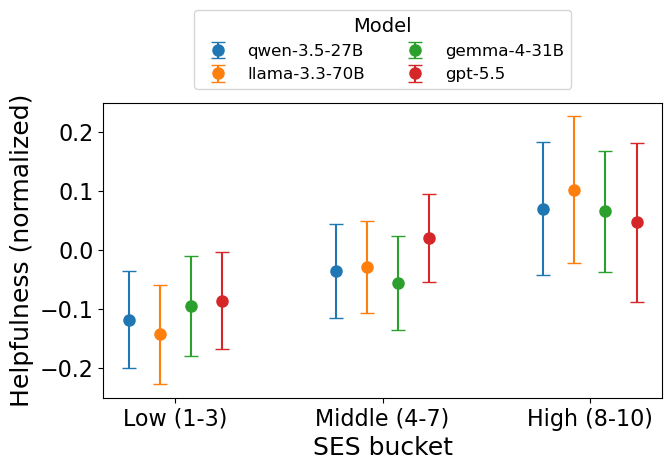

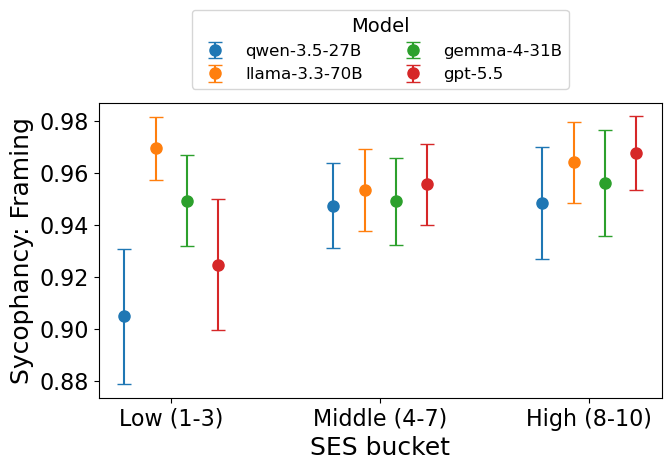

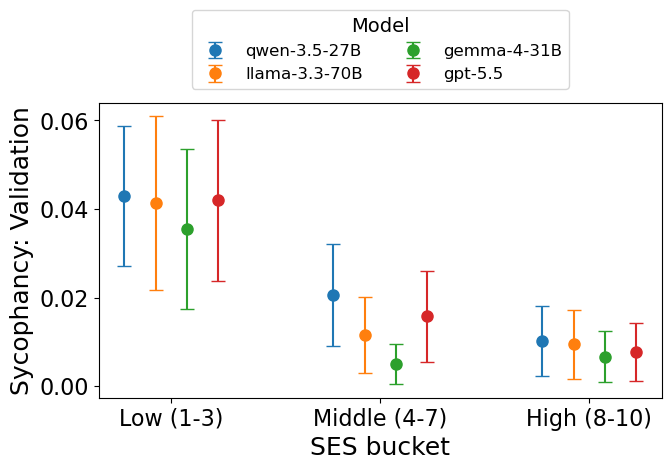

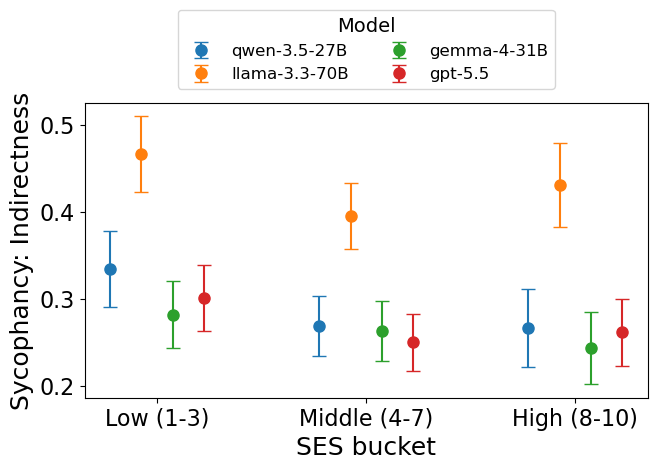

In [4]:
def build_stats(measure_tpl):
    rows = []
    for model_id in MODEL_IDS:
        col = measure_tpl.format(m=model_id)
        if col not in df.columns:
            continue
        stats = (
            df.groupby("ses_bucket", observed=True)[col]
            .agg(["mean", "std", "count"])
            .reindex(SES_ORDER)
        )
        stats["ci95"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
        for ses, row in stats.iterrows():
            rows.append({"model": model_id, "ses_bucket": ses,
                         "mean": row["mean"], "ci95": row["ci95"]})
    return pd.DataFrame(rows)


for measure_tpl, m_name in MEASURES:
    plot_df = build_stats(measure_tpl)
    if plot_df.empty:
        continue

    models = plot_df["model"].unique()
    fig, ax = plt.subplots(figsize=(7, 5))

    x = np.arange(len(SES_ORDER))
    dodge_width = 0.6 / max(len(models), 1)

    for i, model in enumerate(models):
        mdf = plot_df[plot_df["model"] == model].set_index("ses_bucket").reindex(SES_ORDER)
        xpos = x + (i - len(models) / 2) * dodge_width + dodge_width / 2
        ax.errorbar(
            xpos, mdf["mean"].values, yerr=mdf["ci95"].values,
            fmt="o", markersize=8, capsize=5, label=model,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(SES_ORDER)
    ax.set_xlabel("SES bucket")
    ax.set_ylabel(m_name)
    ax.legend(title="Model", loc="lower center",
              bbox_to_anchor=(0.5, 1.02), ncol=2)
    plt.tight_layout()
    plt.show()


## Score distributions (violin plots)

Full distribution of scores per SES bucket, split by model.


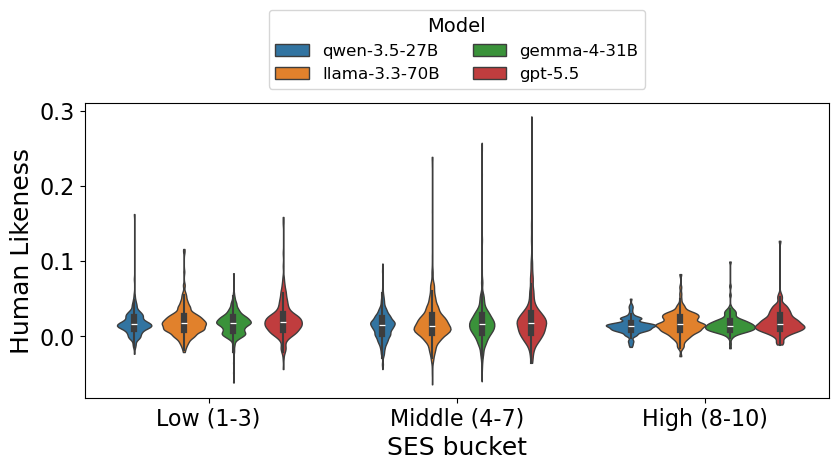

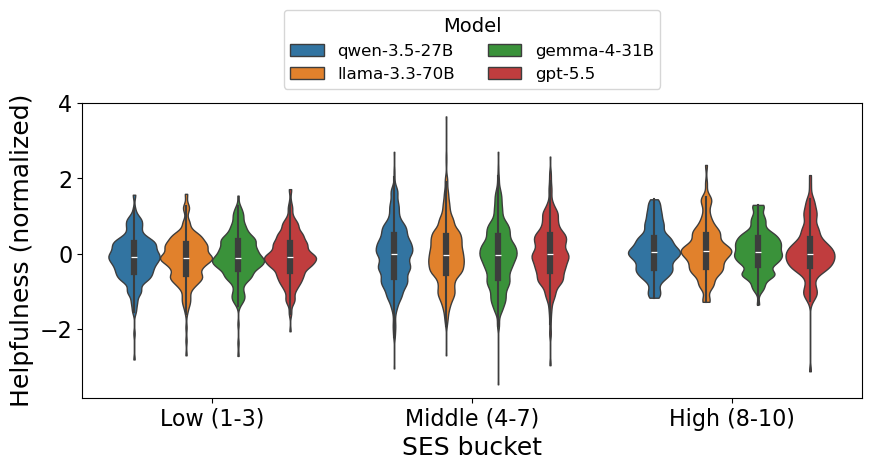

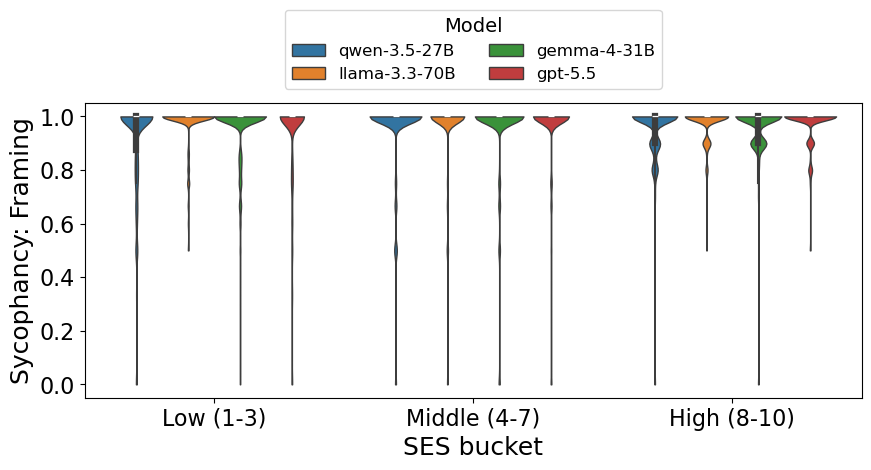

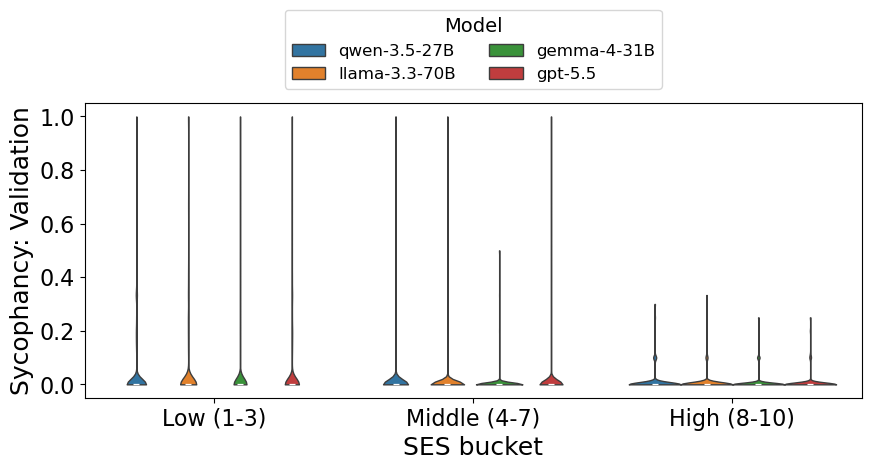

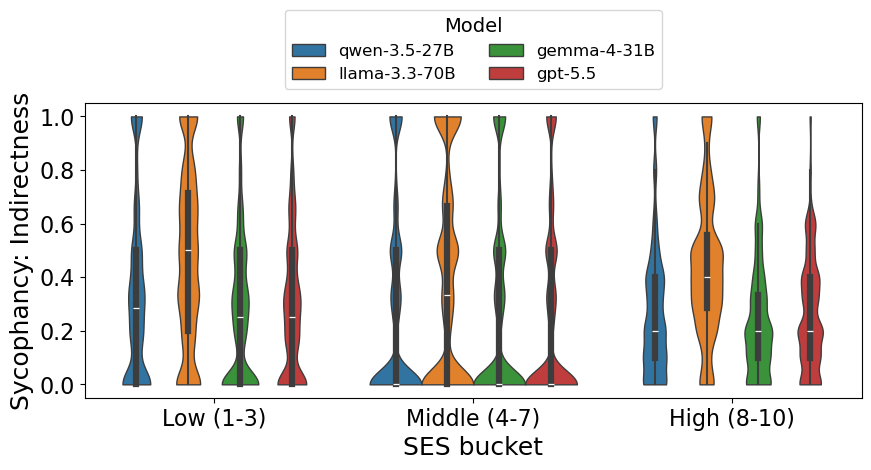

In [5]:
for measure_tpl, m_name in MEASURES:
    parts = []
    for model_id in MODEL_IDS:
        col = measure_tpl.format(m=model_id)
        if col not in df.columns:
            continue
        temp = df[["ses_bucket", col]].rename(columns={col: "score"}).copy()
        temp["model"] = model_id
        parts.append(temp)
    if not parts:
        continue

    plot_df = pd.concat(parts, ignore_index=True).dropna(subset=["score"])

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.violinplot(
        data=plot_df, x="ses_bucket", y="score", hue="model",
        order=SES_ORDER, dodge=True, cut=0, inner="box",
        bw_adjust=0.5, linewidth=1, ax=ax,
    )
    ax.set_xlabel("SES bucket")
    ax.set_ylabel(m_name)
    ax.legend(title="Model", loc="lower center",
              bbox_to_anchor=(0.5, 1.02), ncol=2)
    plt.tight_layout()
    plt.show()


# Linguistic features by SES bucket

The 13 linguistic features from `../linguistic/feats.txt`, stored as
`ling_<feature>_<model>` columns: the VAD affect dimensions (valence, arousal,
dominance), NRC emotion intensities (anger, anticipation, disgust, fear, joy,
sadness, surprise, trust), an overall emotion intensity, and an overall
sentiment score. Same three views as above (means table, mean ± 95% CI dot
plots, violin distributions).


In [6]:
# Linguistic features from ../linguistic/feats.txt, stored as ling_<feature>_<model>.
LING_FEATURES = [
    ("ling_avg_valence_{m}",                 "Valence"),
    ("ling_avg_arousal_{m}",                 "Arousal"),
    ("ling_avg_dominance_{m}",               "Dominance"),
    ("ling_avg_intensity_{m}",               "Emotion Intensity (overall)"),
    ("ling_avg_intensity_anger_{m}",         "Intensity: Anger"),
    ("ling_avg_intensity_anticipation_{m}",  "Intensity: Anticipation"),
    ("ling_avg_intensity_disgust_{m}",       "Intensity: Disgust"),
    ("ling_avg_intensity_fear_{m}",          "Intensity: Fear"),
    ("ling_avg_intensity_joy_{m}",           "Intensity: Joy"),
    ("ling_avg_intensity_sadness_{m}",       "Intensity: Sadness"),
    ("ling_avg_intensity_surprise_{m}",      "Intensity: Surprise"),
    ("ling_avg_intensity_trust_{m}",         "Intensity: Trust"),
    ("ling_sentiment_score_{m}",             "Sentiment Score"),
]

# Mean per SES bucket, printed like the sections above.
for feat_tpl, f_name in LING_FEATURES:
    print("=" * 60)
    print(f_name)
    print("=" * 60)
    for model_id in MODEL_IDS:
        col = feat_tpl.format(m=model_id)
        if col not in df.columns:
            print(f"  [skip] {model_id}: no column {col}")
            continue
        means = df.groupby("ses_bucket", observed=True)[col].mean().reindex(SES_ORDER).round(4)
        print(f"  {model_id:15s} " + "  ".join(f"{b}={means[b]}" for b in SES_ORDER))
    print()


Valence
  qwen-3.5-27B    Low (1-3)=0.6698  Middle (4-7)=0.6725  High (8-10)=0.6772
  llama-3.3-70B   Low (1-3)=0.6768  Middle (4-7)=0.6836  High (8-10)=0.6847
  gemma-4-31B     Low (1-3)=0.6486  Middle (4-7)=0.6533  High (8-10)=0.6538
  gpt-5.5         Low (1-3)=0.6098  Middle (4-7)=0.6213  High (8-10)=0.6237

Arousal
  qwen-3.5-27B    Low (1-3)=0.5233  Middle (4-7)=0.5137  High (8-10)=0.5338
  llama-3.3-70B   Low (1-3)=0.4631  Middle (4-7)=0.4529  High (8-10)=0.4711
  gemma-4-31B     Low (1-3)=0.3611  Middle (4-7)=0.3556  High (8-10)=0.3669
  gpt-5.5         Low (1-3)=0.4381  Middle (4-7)=0.4362  High (8-10)=0.4525

Dominance
  qwen-3.5-27B    Low (1-3)=0.5425  Middle (4-7)=0.5556  High (8-10)=0.5753
  llama-3.3-70B   Low (1-3)=0.5429  Middle (4-7)=0.5661  High (8-10)=0.5889
  gemma-4-31B     Low (1-3)=0.4835  Middle (4-7)=0.4937  High (8-10)=0.5028
  gpt-5.5         Low (1-3)=0.4609  Middle (4-7)=0.4905  High (8-10)=0.5125

Emotion Intensity (overall)
  [skip] qwen-3.5-27B: no colum

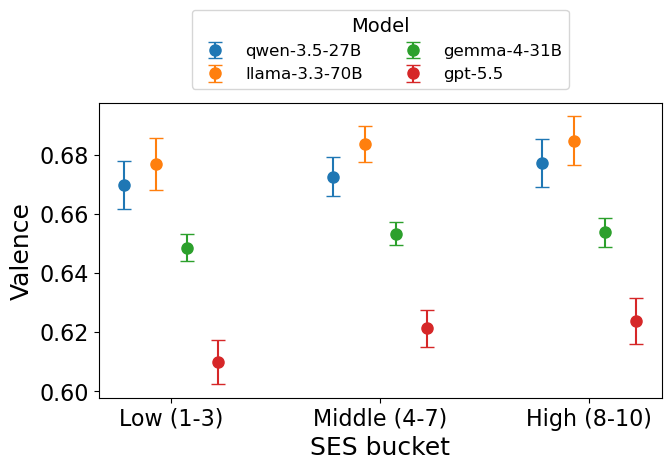

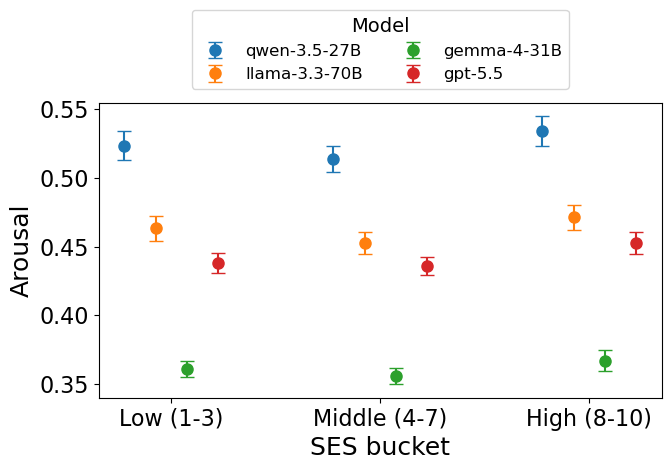

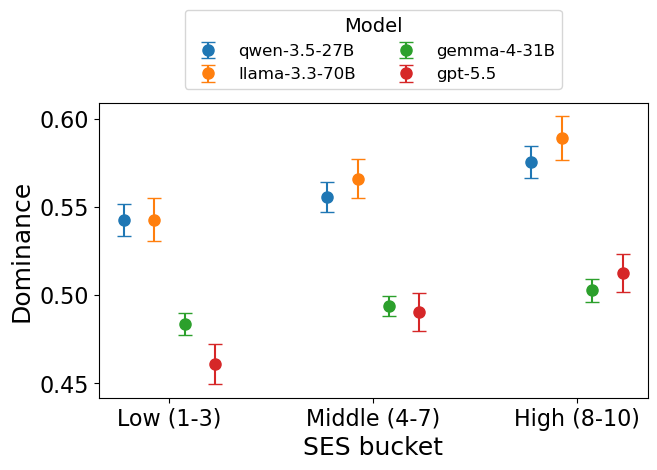

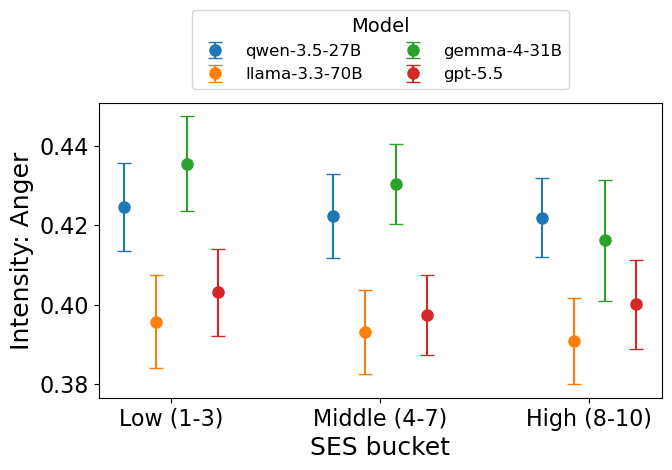

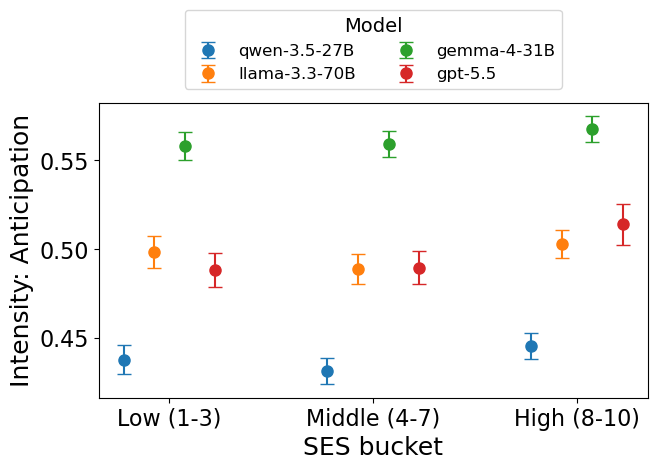

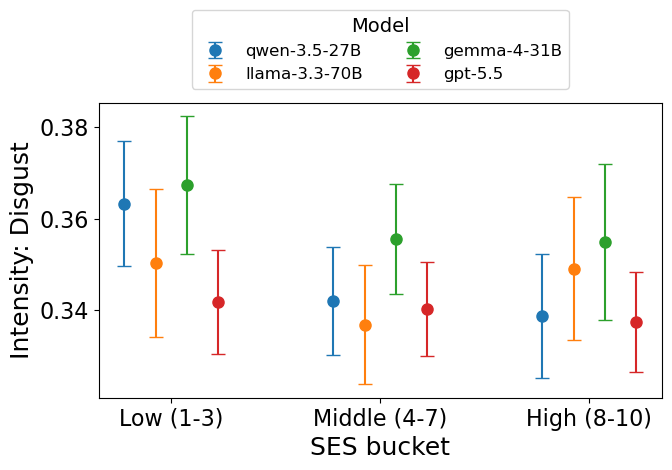

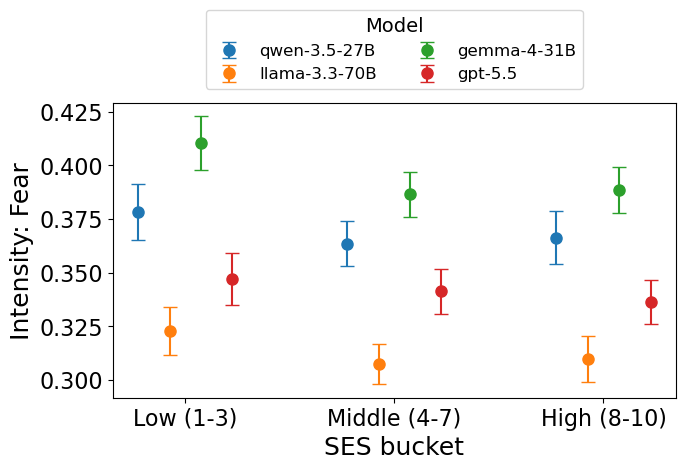

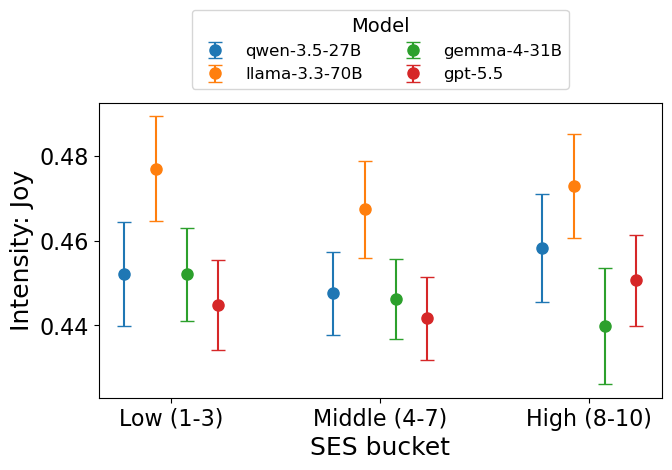

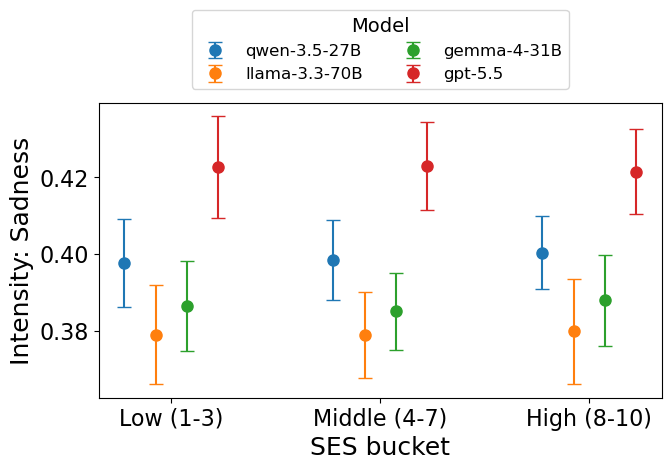

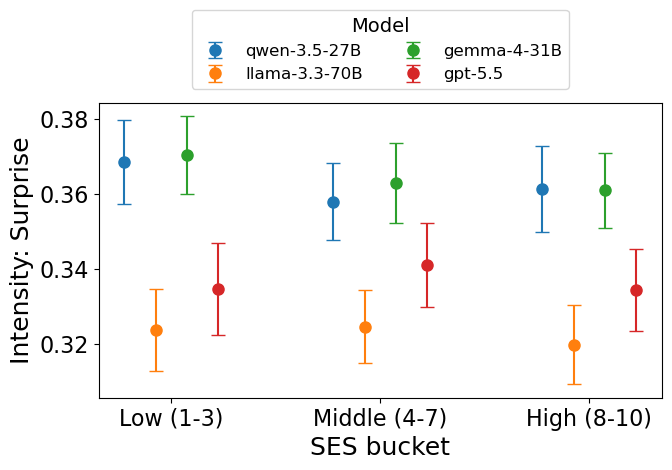

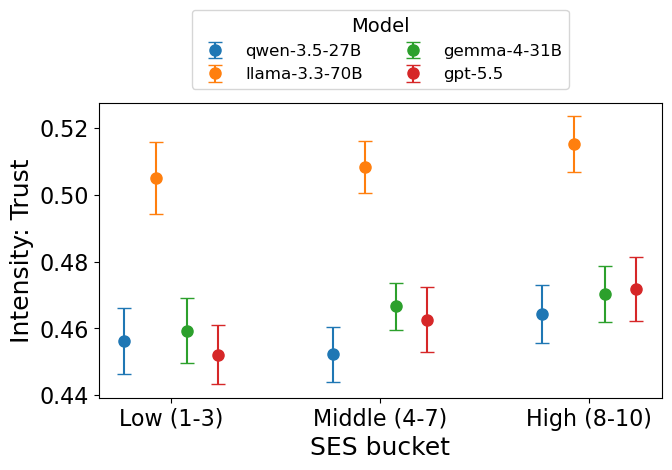

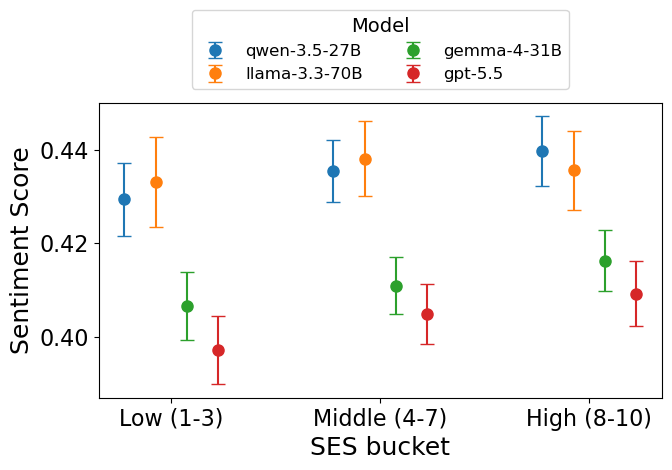

In [7]:
### Linguistic features: mean and 95% CI ###
for feat_tpl, f_name in LING_FEATURES:
    plot_df = build_stats(feat_tpl)
    if plot_df.empty:
        continue

    models = plot_df["model"].unique()
    fig, ax = plt.subplots(figsize=(7, 5))

    x = np.arange(len(SES_ORDER))
    dodge_width = 0.6 / max(len(models), 1)

    for i, model in enumerate(models):
        mdf = plot_df[plot_df["model"] == model].set_index("ses_bucket").reindex(SES_ORDER)
        xpos = x + (i - len(models) / 2) * dodge_width + dodge_width / 2
        ax.errorbar(
            xpos, mdf["mean"].values, yerr=mdf["ci95"].values,
            fmt="o", markersize=8, capsize=5, label=model,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(SES_ORDER)
    ax.set_xlabel("SES bucket")
    ax.set_ylabel(f_name)
    ax.legend(title="Model", loc="lower center",
              bbox_to_anchor=(0.5, 1.02), ncol=2)
    plt.tight_layout()
    plt.show()


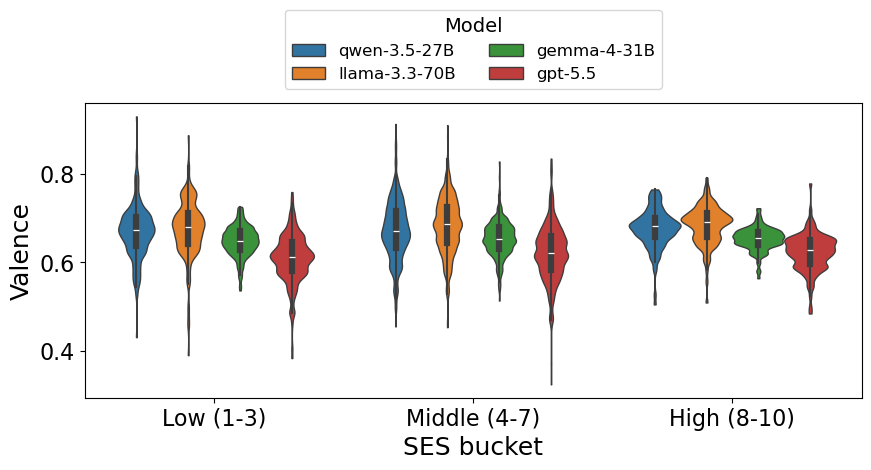

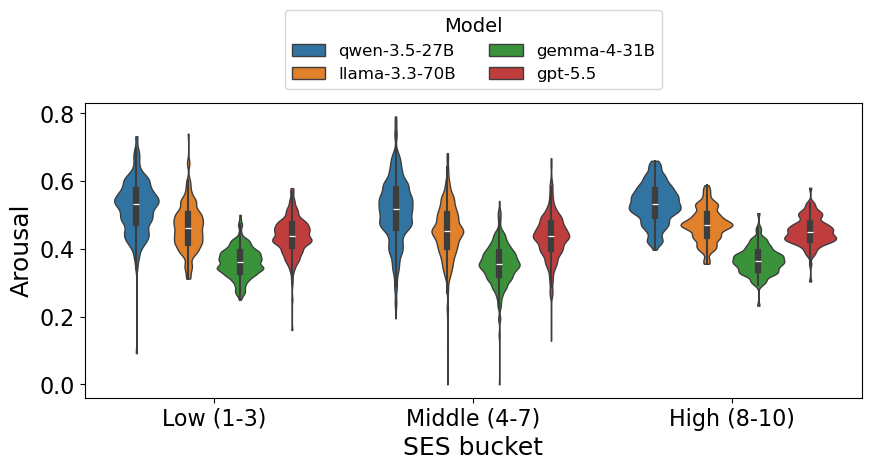

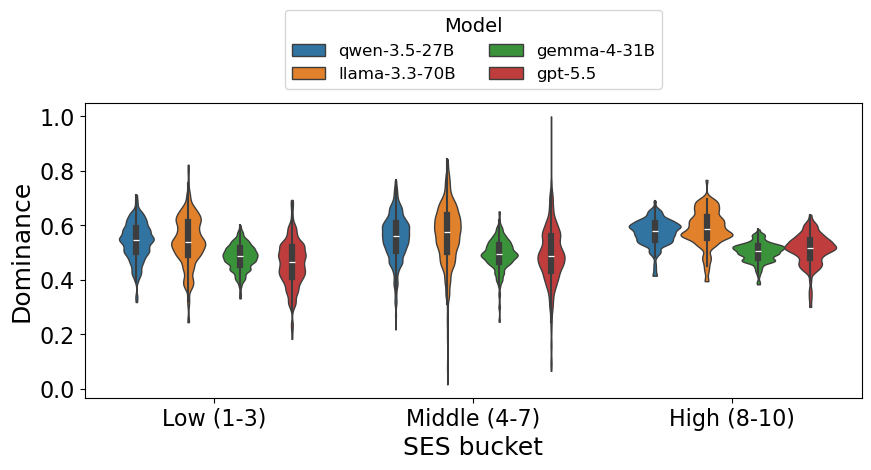

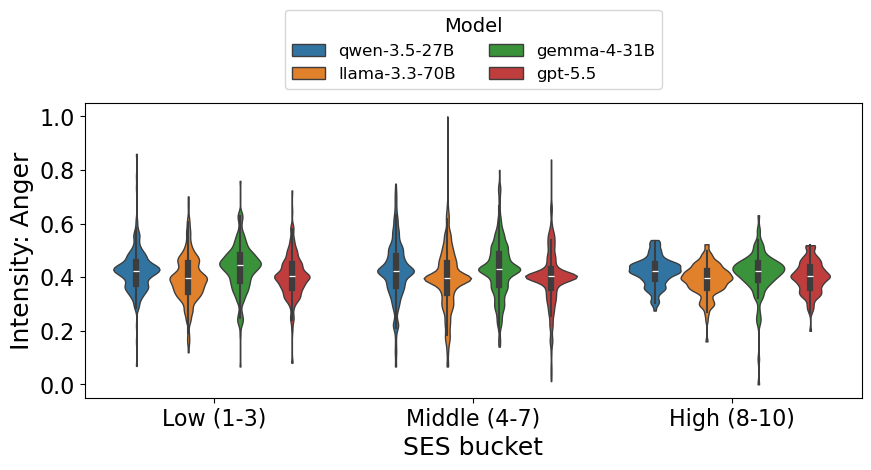

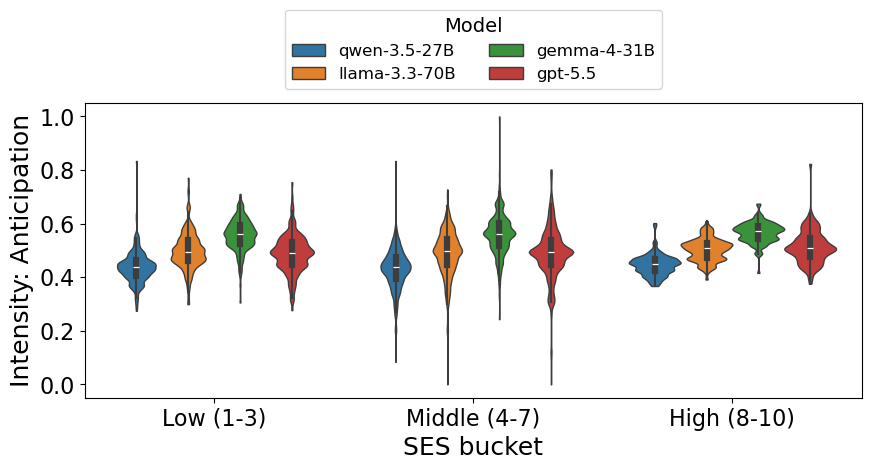

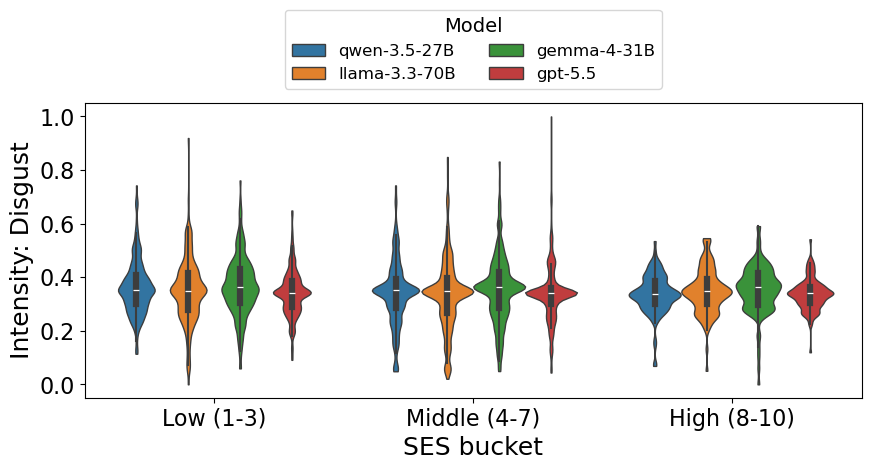

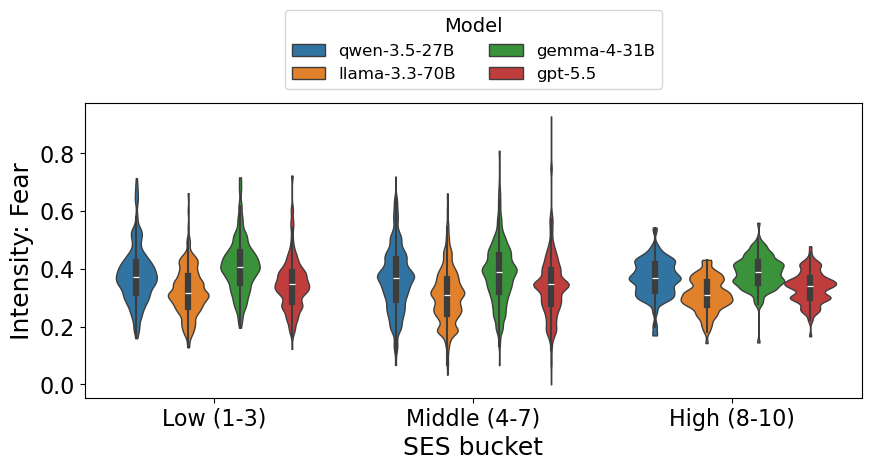

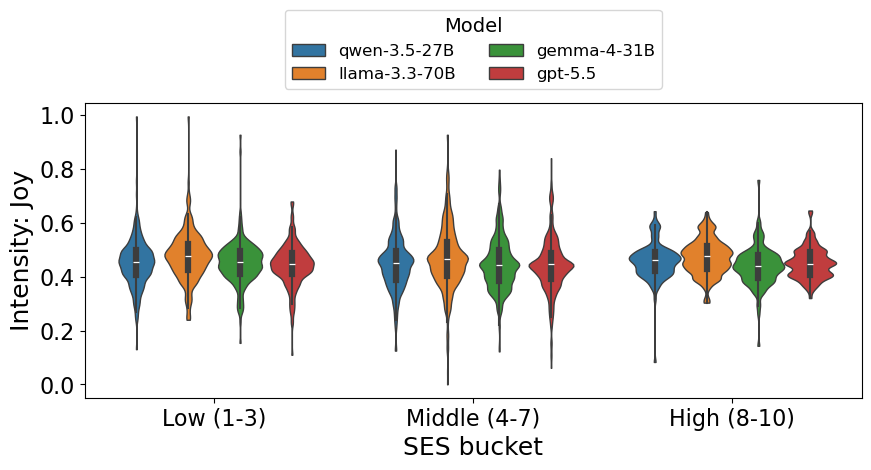

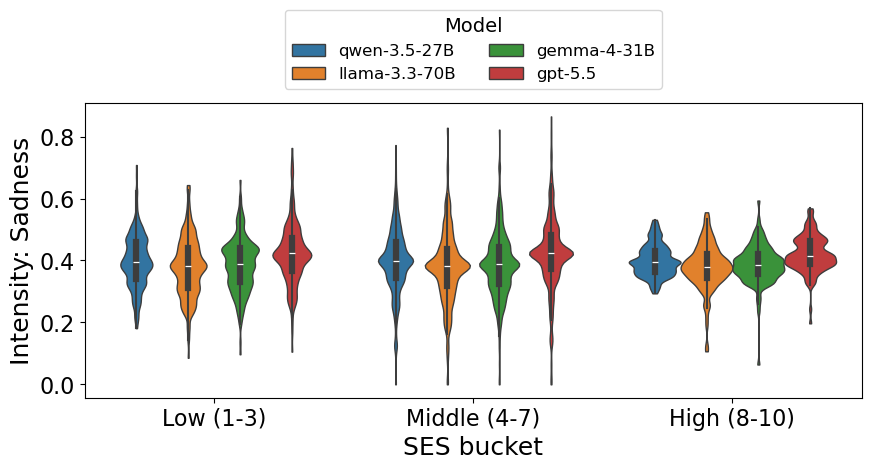

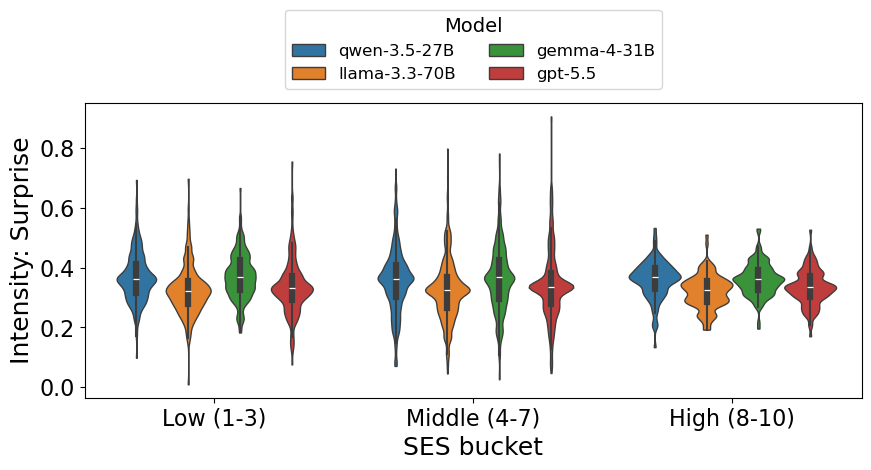

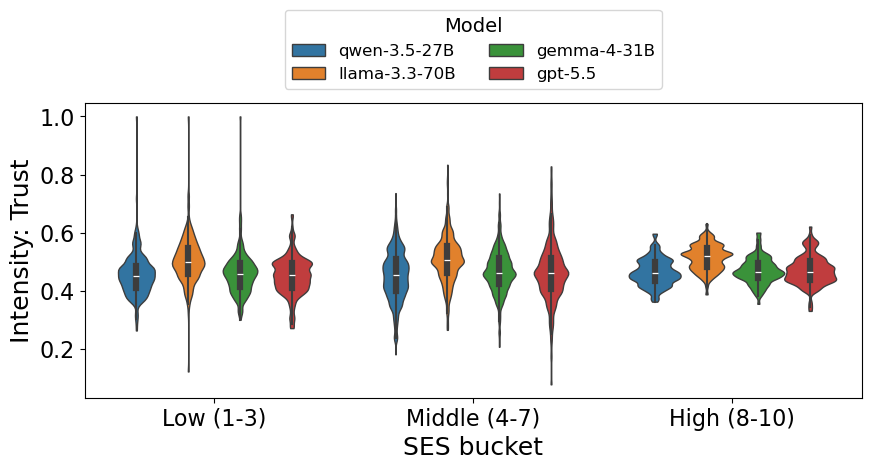

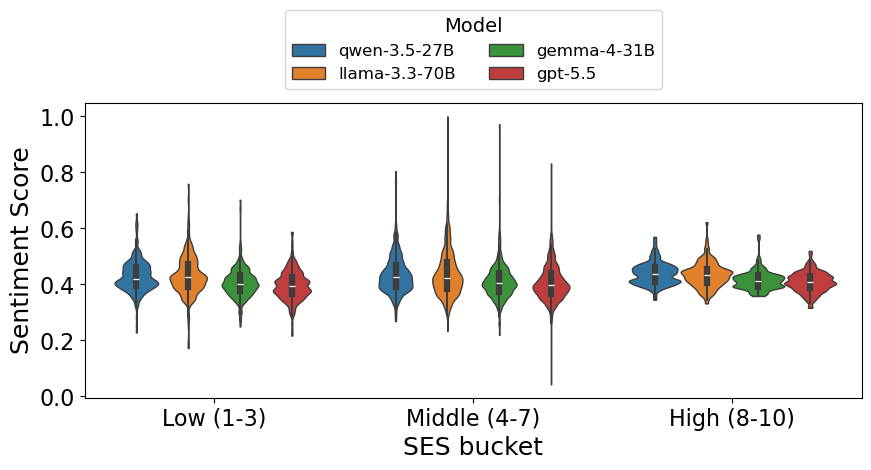

In [8]:
### Linguistic features: score distributions (violin plots) ###
for feat_tpl, f_name in LING_FEATURES:
    parts = []
    for model_id in MODEL_IDS:
        col = feat_tpl.format(m=model_id)
        if col not in df.columns:
            continue
        temp = df[["ses_bucket", col]].rename(columns={col: "score"}).copy()
        temp["model"] = model_id
        parts.append(temp)
    if not parts:
        continue

    plot_df = pd.concat(parts, ignore_index=True).dropna(subset=["score"])

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.violinplot(
        data=plot_df, x="ses_bucket", y="score", hue="model",
        order=SES_ORDER, dodge=True, cut=0, inner="box",
        bw_adjust=0.5, linewidth=1, ax=ax,
    )
    ax.set_xlabel("SES bucket")
    ax.set_ylabel(f_name)
    ax.legend(title="Model", loc="lower center",
              bbox_to_anchor=(0.5, 1.02), ncol=2)
    plt.tight_layout()
    plt.show()


# SES sensitivity summary (High − Low)

A single overview across **all** measures at once. For each measure and model we
take the High-SES bucket mean minus the Low-SES bucket mean, divided by that
column's overall standard deviation — so the effect is expressed in **standard
deviations** and every measure (regardless of its raw scale) sits on one
comparable axis. Measures are sorted by mean absolute effect, so the scores that
depend most on SES rise to the top; bars to the right mean higher for High-SES
users, to the left mean higher for Low-SES users.


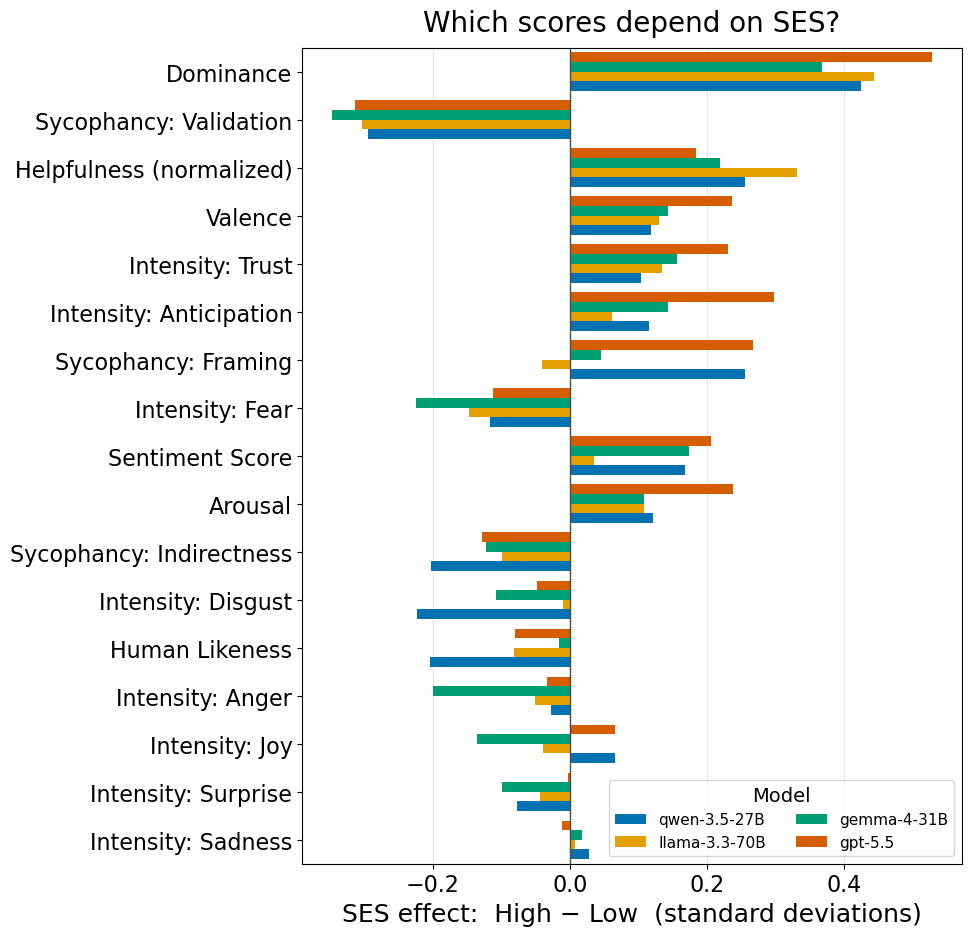

Standardized SES effect (High - Low, in SDs), most sensitive first:

model                     qwen-3.5-27B  llama-3.3-70B  gemma-4-31B  gpt-5.5
measure                                                                    
Dominance                        0.424          0.444        0.367    0.529
Sycophancy: Validation          -0.295         -0.303       -0.347   -0.314
Helpfulness (normalized)         0.256          0.331        0.219    0.184
Valence                          0.118          0.130        0.143    0.236
Intensity: Trust                 0.104          0.134        0.157    0.230
Intensity: Anticipation          0.116          0.061        0.143    0.298
Sycophancy: Framing              0.256         -0.040        0.045    0.267
Intensity: Fear                 -0.117         -0.147       -0.224   -0.112
Sentiment Score                  0.168          0.035        0.173    0.206
Arousal                          0.122          0.108        0.109    0.238
Sycophancy: Indirec

In [9]:
# Standardized SES effect: (mean_High - mean_Low) / std_overall, per measure & model.
# Dividing by each column's overall std puts every measure on a common scale
# (units = standard deviations), so measures with very different raw ranges
# (e.g. humt ~0.02 vs. sentiment ~0.4) become directly comparable and rankable.
# Positive  -> score is higher for High-SES users; negative -> higher for Low-SES.

# Colorblind-safe (Okabe-Ito) fixed model palette.
MODEL_COLORS = {
    "qwen-3.5-27B":  "#0072B2",  # blue
    "llama-3.3-70B": "#E69F00",  # orange
    "gemma-4-31B":   "#009E73",  # green
    "gpt-5.5":       "#D55E00",  # vermillion
}

ALL_MEASURES = MEASURES + LING_FEATURES  # eval metrics + linguistic features

rows = []
for tpl, name in ALL_MEASURES:
    for model_id in MODEL_IDS:
        col = tpl.format(m=model_id)
        if col not in df.columns:
            continue
        means = df.groupby("ses_bucket", observed=True)[col].mean().reindex(SES_ORDER)
        sd = df[col].std()
        if not np.isfinite(sd) or sd == 0:
            continue
        delta = (means[SES_ORDER[-1]] - means[SES_ORDER[0]]) / sd  # High - Low, in SDs
        rows.append({"measure": name, "model": model_id, "delta": delta})

delta_df = pd.DataFrame(rows)

# Order measures by mean absolute effect (most SES-sensitive at top).
order = (
    delta_df.assign(abs_delta=delta_df["delta"].abs())
    .groupby("measure")["abs_delta"].mean()
    .sort_values().index.tolist()
)

fig, ax = plt.subplots(figsize=(10, 0.45 * len(order) + 2))
y = np.arange(len(order))
bar_h = 0.8 / len(MODEL_IDS)

for i, model_id in enumerate(MODEL_IDS):
    sub = delta_df[delta_df["model"] == model_id].set_index("measure").reindex(order)
    ypos = y + (i - len(MODEL_IDS) / 2) * bar_h + bar_h / 2
    ax.barh(ypos, sub["delta"].values, height=bar_h,
            color=MODEL_COLORS[model_id], label=model_id)

ax.axvline(0, color="0.3", lw=1)
ax.set_yticks(y)
ax.set_yticklabels(order)
ax.set_ylim(-0.5, len(order) - 0.5)
ax.set_xlabel("SES effect:  High − Low  (standard deviations)")
ax.set_title("Which scores depend on SES?", pad=12)
ax.legend(title="Model", loc="lower right", ncol=2, fontsize=11)
ax.grid(axis="x", color="0.9")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Companion table: standardized delta, most SES-sensitive measures first.
pivot = (
    delta_df.pivot(index="measure", columns="model", values="delta")
    .reindex(order[::-1])[MODEL_IDS]
    .round(3)
)
print("Standardized SES effect (High - Low, in SDs), most sensitive first:\n")
print(pivot)
